In [21]:
import pandas as pd
import numpy as np

In [22]:
from pathlib import Path
import pandas as pd

# Determine project root (works when running from the notebooks folder)
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
csv_path = root / "data" / "raw" / "mini-manual-survey-results.csv"
print("Reading:", csv_path)
df = pd.read_csv(csv_path)

Reading: c:\cosmos\26-the-pattern-seekers-analysis\mini-manual-survey\data\raw\mini-manual-survey-results.csv


In [23]:
from pathlib import Path
import pandas as pd

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
csv_path = root / "data" / "raw" / "mini-manual-survey-results.csv"
print("Reading:", csv_path)
df = pd.read_csv(csv_path)

Reading: c:\cosmos\26-the-pattern-seekers-analysis\mini-manual-survey\data\raw\mini-manual-survey-results.csv


In [24]:
df.head()

,Timestamp,"Please enter your full name in the following format: Last name first separated by a comma and single whitespace and then your first name. (e.g. Doe, John).",What time did you sleep yesterday?,What time did you wake up today?,How refreshed do you feel today?
0,2026/07/07 11:44:48 AM MDT,"Liu, William",00:30,07:00,4
1,2026/07/07 11:44:49 AM MDT,"Tang, Michael",23:45,06:50,3
2,2026/07/07 11:44:56 AM MDT,"Su, Warren",00:45,07:30,2
3,2026/07/07 11:45:02 AM MDT,"Park, Brendan",23:06,06:56,4
4,2026/07/07 11:45:03 AM MDT,"Wang, Yuchen",23:30,06:45,4


In [25]:
df.head(18)

,Timestamp,"Please enter your full name in the following format: Last name first separated by a comma and single whitespace and then your first name. (e.g. Doe, John).",What time did you sleep yesterday?,What time did you wake up today?,How refreshed do you feel today?
0,2026/07/07 11:44:48 AM MDT,"Liu, William",00:30,07:00,4
1,2026/07/07 11:44:49 AM MDT,"Tang, Michael",23:45,06:50,3
2,2026/07/07 11:44:56 AM MDT,"Su, Warren",00:45,07:30,2
3,2026/07/07 11:45:02 AM MDT,"Park, Brendan",23:06,06:56,4
4,2026/07/07 11:45:03 AM MDT,"Wang, Yuchen",23:30,06:45,4
5,2026/07/07 11:45:25 AM MDT,"Kaludjerovic, Ema",23:00,07:00,3
6,2026/07/07 11:45:41 AM MDT,Brian Qian,23:43,06:58,2
7,2026/07/07 11:45:45 AM MDT,"Nanniyur, Anirudh",00:00,07:30,3
8,2026/07/07 11:45:48 AM MDT,"Castillo, Rachel",23:30,06:45,3
9,2026/07/07 11:46:21 AM MDT,"Jain, Shely",23:30,07:15,4


In [26]:
# Parse times, compute total sleep duration, and format times
from datetime import datetime

# helper: parse H:M or H:M:S to minutes since midnight
def to_minutes(t):
    if pd.isna(t):
        return None
    s = str(t).strip()
    if s == '':
        return None
    for fmt in ("%H:%M", "%H:%M:%S"):
        try:
            dt = datetime.strptime(s, fmt)
            return dt.hour * 60 + dt.minute + dt.second / 60
        except Exception:
            continue
    return None

# apply parsing
sleep_col = 'What time did you sleep yesterday?'
wake_col = 'What time did you wake up today?'

df['_sleep_min'] = df[sleep_col].apply(to_minutes)
df['_wake_min'] = df[wake_col].apply(to_minutes)

def compute_total(row):
    s = row.get('_sleep_min')
    w = row.get('_wake_min')
    if s is None or w is None:
        return pd.NaT
    s = float(s); w = float(w)
    if s <= w:
        mins = w - s
    else:
        mins = (24*60 - s) + w
    return pd.to_timedelta(mins, unit='m')

# add column
df['Total Sleep Time'] = df.apply(compute_total, axis=1)

# convert original time columns to ISO HH:MM:SS when possible
def to_iso(t):
    if pd.isna(t):
        return t
    s = str(t).strip()
    for fmt in ("%H:%M", "%H:%M:%S"):
        try:
            dt = datetime.strptime(s, fmt)
            return dt.strftime('%H:%M:%S')
        except Exception:
            continue
    return t

df[sleep_col] = df[sleep_col].apply(to_iso)
df[wake_col] = df[wake_col].apply(to_iso)

# cleanup
if '_sleep_min' in df.columns:
    df.drop(columns=['_sleep_min'], inplace=True)
if '_wake_min' in df.columns:
    df.drop(columns=['_wake_min'], inplace=True)

# show results
print(df[[sleep_col, wake_col, 'Total Sleep Time']].head())


  What time did you sleep yesterday? What time did you wake up today?  \
0                           00:30:00                         07:00:00   
1                           23:45:00                         06:50:00   
2                           00:45:00                         07:30:00   
3                           23:06:00                         06:56:00   
4                           23:30:00                         06:45:00   

  Total Sleep Time  
0  0 days 06:30:00  
1  0 days 07:05:00  
2  0 days 06:45:00  
3  0 days 07:50:00  
4  0 days 07:15:00  


In [27]:
df.head()

,Timestamp,"Please enter your full name in the following format: Last name first separated by a comma and single whitespace and then your first name. (e.g. Doe, John).",What time did you sleep yesterday?,What time did you wake up today?,How refreshed do you feel today?,Total Sleep Time
0,2026/07/07 11:44:48 AM MDT,"Liu, William",00:30:00,07:00:00,4,0 days 06:30:00
1,2026/07/07 11:44:49 AM MDT,"Tang, Michael",23:45:00,06:50:00,3,0 days 07:05:00
2,2026/07/07 11:44:56 AM MDT,"Su, Warren",00:45:00,07:30:00,2,0 days 06:45:00
3,2026/07/07 11:45:02 AM MDT,"Park, Brendan",23:06:00,06:56:00,4,0 days 07:50:00
4,2026/07/07 11:45:03 AM MDT,"Wang, Yuchen",23:30:00,06:45:00,4,0 days 07:15:00


In [28]:
# Convert `Total Sleep Time` to integer hours (floor) and show sample
hours = df['Total Sleep Time'].dt.total_seconds() / 3600
# produce nullable integer column with floor hours
df['Total Sleep Hours (int)'] = hours.apply(lambda x: pd.NA if pd.isna(x) else int(x)).astype('Int64')

print(df[[sleep_col, wake_col, 'Total Sleep Time', 'Total Sleep Hours (int)']].head())

  What time did you sleep yesterday? What time did you wake up today?  \
0                           00:30:00                         07:00:00   
1                           23:45:00                         06:50:00   
2                           00:45:00                         07:30:00   
3                           23:06:00                         06:56:00   
4                           23:30:00                         06:45:00   

  Total Sleep Time  Total Sleep Hours (int)  
0  0 days 06:30:00                        6  
1  0 days 07:05:00                        7  
2  0 days 06:45:00                        6  
3  0 days 07:50:00                        7  
4  0 days 07:15:00                        7  


In [29]:
df.head()

,Timestamp,"Please enter your full name in the following format: Last name first separated by a comma and single whitespace and then your first name. (e.g. Doe, John).",What time did you sleep yesterday?,What time did you wake up today?,How refreshed do you feel today?,Total Sleep Time,Total Sleep Hours (int)
0,2026/07/07 11:44:48 AM MDT,"Liu, William",00:30:00,07:00:00,4,0 days 06:30:00,6
1,2026/07/07 11:44:49 AM MDT,"Tang, Michael",23:45:00,06:50:00,3,0 days 07:05:00,7
2,2026/07/07 11:44:56 AM MDT,"Su, Warren",00:45:00,07:30:00,2,0 days 06:45:00,6
3,2026/07/07 11:45:02 AM MDT,"Park, Brendan",23:06:00,06:56:00,4,0 days 07:50:00,7
4,2026/07/07 11:45:03 AM MDT,"Wang, Yuchen",23:30:00,06:45:00,4,0 days 07:15:00,7


Reading: c:\cosmos\26-the-pattern-seekers-analysis\mini-manual-survey\data\raw\mini-manual-survey-results.csv


C:\Users\elapr\AppData\Local\Temp\ipykernel_12508\2136819701.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sleep_Hours_Int', y='Refreshed', data=df, ax=ax, palette='Pastel1')


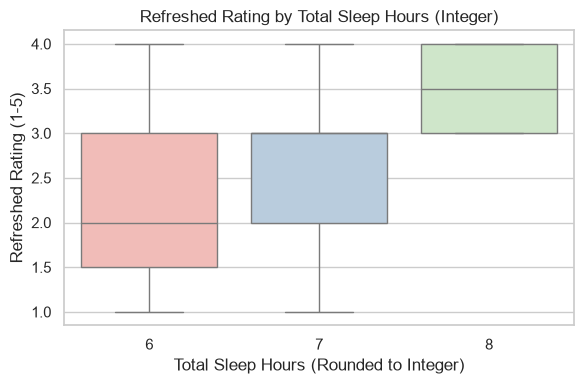

C:\Users\elapr\AppData\Local\Temp\ipykernel_12508\2136819701.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Refreshed', y='Sleep_Duration_Hours', data=df, ax=ax, palette='Set2')


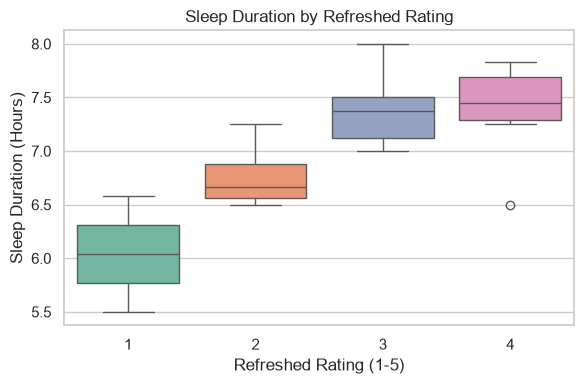

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load data and clean column names
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
csv_path = root / "data" / "raw" / "mini-manual-survey-results.csv"
print("Reading:", csv_path)
df = pd.read_csv(csv_path)
df.columns = ['Timestamp', 'Name', 'SleepTime', 'WakeTime', 'Refreshed']

# 2. Function to convert time string (HH:MM) to minutes
def time_to_minutes(t_str):
    h, m = map(int, t_str.strip().split(':'))
    return h * 60 + m

df['Sleep_Min'] = df['SleepTime'].apply(time_to_minutes)
df['Wake_Min'] = df['WakeTime'].apply(time_to_minutes)

# 3. Calculate absolute sleep duration hours (handling times that cross midnight)
df['Sleep_Duration_Hours'] = df.apply(
    lambda row: (row['Wake_Min'] - row['Sleep_Min']) / 60.0 if row['Sleep_Min'] < row['Wake_Min']
    else (1440 - row['Sleep_Min'] + row['Wake_Min']) / 60.0, axis=1
)

# 4. Convert sleep duration to integer values (rounded to the nearest hour)
df['Sleep_Hours_Int'] = df['Sleep_Duration_Hours'].round().astype(int)

# Set seaborn styling for clean visuals
sns.set_theme(style="whitegrid")

# Plot 1: Box plot of Refreshed Rating grouped by Integer Sleep Hours
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='Sleep_Hours_Int', y='Refreshed', data=df, ax=ax, palette='Pastel1')
ax.set_title('Refreshed Rating by Total Sleep Hours (Integer)')
ax.set_xlabel('Total Sleep Hours (Rounded to Integer)')
ax.set_ylabel('Refreshed Rating (1-5)')
plt.tight_layout()
plt.savefig('boxplot_refreshed_by_sleep_int.png')
plt.show()
plt.close()

# Plot 2: Box plot of Exact Sleep Hours grouped by Refreshed Rating Category
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='Refreshed', y='Sleep_Duration_Hours', data=df, ax=ax, palette='Set2')
ax.set_title('Sleep Duration by Refreshed Rating')
ax.set_xlabel('Refreshed Rating (1-5)')
ax.set_ylabel('Sleep Duration (Hours)')
plt.tight_layout()
plt.savefig('boxplot_sleep_by_refreshed.png')
plt.show()
plt.close()

In [ ]:
df.head(20)

,Timestamp,Name,SleepTime,WakeTime,Refreshed,Sleep_Min,Wake_Min,Sleep_Duration_Hours,Sleep_Hours_Int
0,2026/07/07 11:44:48 AM MDT,"Liu, William",00:30,07:00,4,30,420,6.500000,6
1,2026/07/07 11:44:49 AM MDT,"Tang, Michael",23:45,06:50,3,1425,410,7.083333,7
2,2026/07/07 11:44:56 AM MDT,"Su, Warren",00:45,07:30,2,45,450,6.750000,7
3,2026/07/07 11:45:02 AM MDT,"Park, Brendan",23:06,06:56,4,1386,416,7.833333,8
4,2026/07/07 11:45:03 AM MDT,"Wang, Yuchen",23:30,06:45,4,1410,405,7.250000,7
5,2026/07/07 11:45:25 AM MDT,"Kaludjerovic, Ema",23:00,07:00,3,1380,420,8.000000,8
6,2026/07/07 11:45:41 AM MDT,Brian Qian,23:43,06:58,2,1423,418,7.250000,7
7,2026/07/07 11:45:45 AM MDT,"Nanniyur, Anirudh",00:00,07:30,3,0,450,7.500000,8
8,2026/07/07 11:45:48 AM MDT,"Castillo, Rachel",23:30,06:45,3,1410,405,7.250000,7
9,2026/07/07 11:46:21 AM MDT,"Jain, Shely",23:30,07:15,4,1410,435,7.750000,8


In [ ]:
df.loc[df['Name'] == "Brian Qian", 'Name'] = "Qian, Brian"

In [ ]:
df = df.drop(['Timestamp'], axis=1)

In [ ]:
df.head(18)

,Name,SleepTime,WakeTime,Refreshed,Sleep_Min,Wake_Min,Sleep_Duration_Hours,Sleep_Hours_Int
0,"Liu, William",00:30,07:00,4,30,420,6.500000,6
1,"Tang, Michael",23:45,06:50,3,1425,410,7.083333,7
2,"Su, Warren",00:45,07:30,2,45,450,6.750000,7
3,"Park, Brendan",23:06,06:56,4,1386,416,7.833333,8
4,"Wang, Yuchen",23:30,06:45,4,1410,405,7.250000,7
5,"Kaludjerovic, Ema",23:00,07:00,3,1380,420,8.000000,8
6,"Qian, Brian",23:43,06:58,2,1423,418,7.250000,7
7,"Nanniyur, Anirudh",00:00,07:30,3,0,450,7.500000,8
8,"Castillo, Rachel",23:30,06:45,3,1410,405,7.250000,7
9,"Jain, Shely",23:30,07:15,4,1410,435,7.750000,8


In [ ]:
df.to_csv('Mini Manual Survey Processed.csv', index=False)